In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
from scipy.signal import convolve2d

from src.gaussian import *
from src.bilateral import *
from src.utilities import *

### Q1 Low Pass Gaussian Filter

In [3]:
P = 5
sigmas = [0.1, 1, 2, 4, 8]

In [4]:
data_dir = 'data/'
ref_img_name = 'img167.bmp'
ref_img = np.array(Image.open(data_dir + ref_img_name)).astype(np.float32)
noisy_img_names = [i for i in os.listdir(data_dir) if i != ref_img_name and i.endswith(('.bmp'))]
noisy_img_names

['img108.bmp', 'img125.bmp', 'img137.bmp', 'img32.bmp', 'img6.bmp']

In [5]:
mse_list = []
for img_name in noisy_img_names:
    image = np.array(Image.open(data_dir + img_name)).astype(np.float32)
    mse_list.append((img_name, float(calculate_mse(image, ref_img))))
sorted_noisy_img_names = sorted(mse_list, key=lambda x: x[1])
sorted_noisy_img_names

[('img125.bmp', 24.76817512512207),
 ('img6.bmp', 79.69729614257812),
 ('img108.bmp', 919.0718383789062),
 ('img32.bmp', 1638.5145263671875),
 ('img137.bmp', 15423.498046875)]

In [6]:
result = {}

for img_name, noise_mse in sorted_noisy_img_names:
    noisy_image = np.array(Image.open(data_dir + img_name)).astype(np.float32)

    best_mse = float('inf')
    best_sigma = float('inf')
    best_denoised_img = None

    for sigma in sigmas:
        gaussian_kernel = createGaussianKernel(P, sigma)
        denoised_img = np.zeros_like(noisy_image)
        for channel in range(3):
            denoised_img[:, :, channel] = convolve2d(noisy_image[:, :, channel], gaussian_kernel, mode='same', boundary='symm')
        denoised_img = np.clip(denoised_img, 0, 255).astype(np.uint8)
        mse = calculate_mse(ref_img, denoised_img)

        if mse < best_mse:
            best_mse = mse
            best_sigma = sigma
            best_denoised_img = denoised_img
        
    result[img_name] = [best_mse, best_sigma, best_denoised_img, noisy_image.astype(np.uint8)]
    print(f"Image_name: {img_name:<12} | Best MSE: {best_mse:<10.2f} | Best Sigma: {best_sigma:<10.1f}")

Image_name: img125.bmp   | Best MSE: 24.77      | Best Sigma: 0.1       
Image_name: img6.bmp     | Best MSE: 79.70      | Best Sigma: 0.1       
Image_name: img108.bmp   | Best MSE: 185.04     | Best Sigma: 1.0       
Image_name: img32.bmp    | Best MSE: 248.24     | Best Sigma: 1.0       
Image_name: img137.bmp   | Best MSE: 1651.68    | Best Sigma: 8.0       


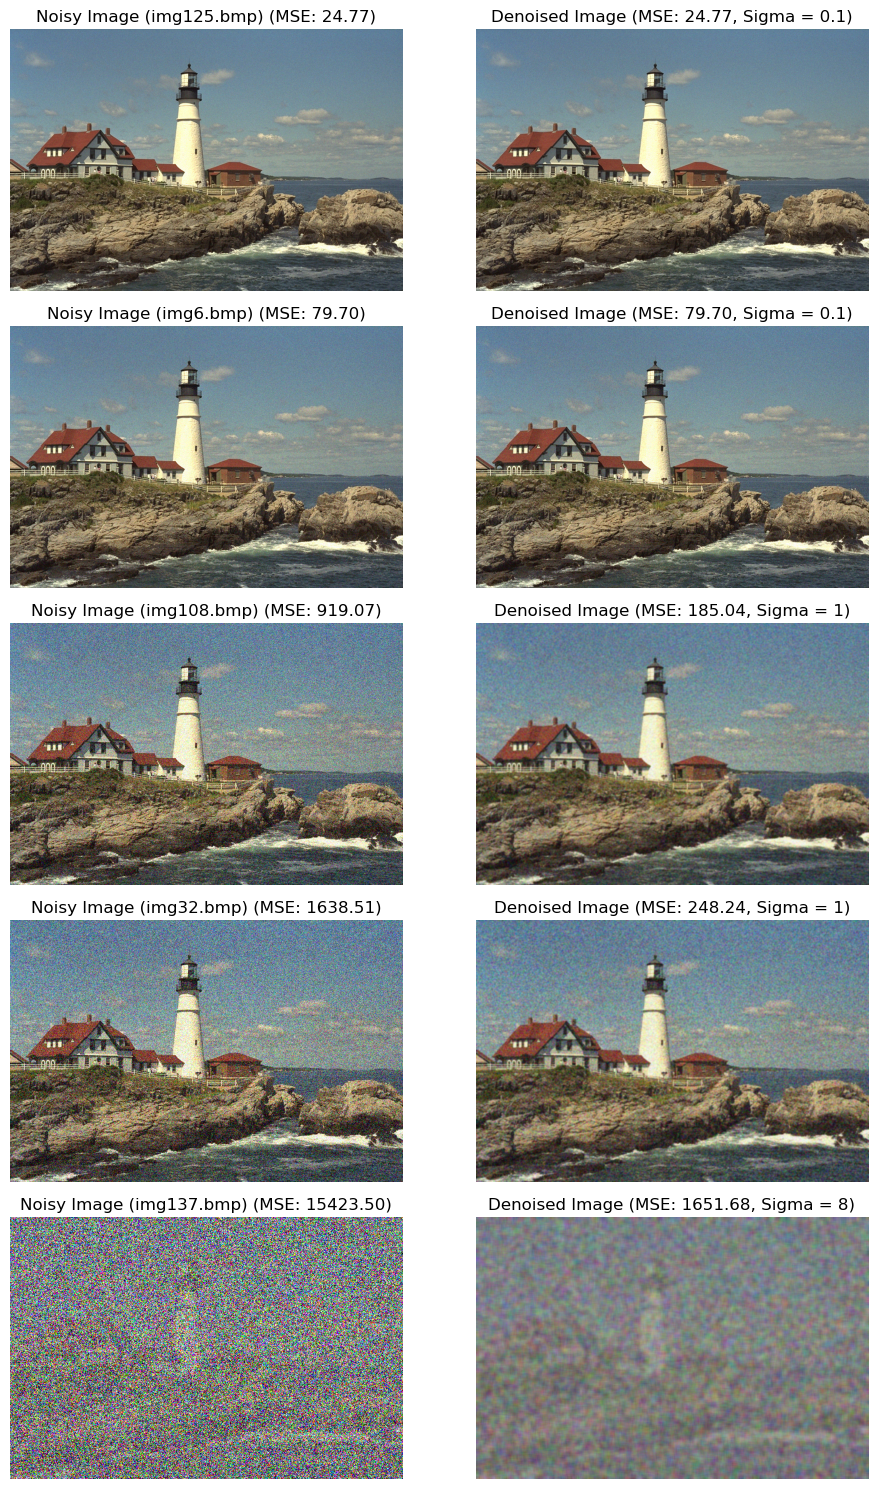

In [7]:
fig, axes = plt.subplots(nrows = 5, ncols = 2, figsize = (10, 15))

for i, (img_name, noisy_mse) in enumerate(sorted_noisy_img_names):
    axes[i, 0].imshow(result[img_name][3], cmap='gray')
    axes[i, 0].set_title(f'Noisy Image ({img_name}) (MSE: {noisy_mse:.2f})')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(result[img_name][2], cmap='gray')
    axes[i, 1].set_title(f'Denoised Image (MSE: {result[img_name][0]:.2f}, Sigma = {result[img_name][1]})')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

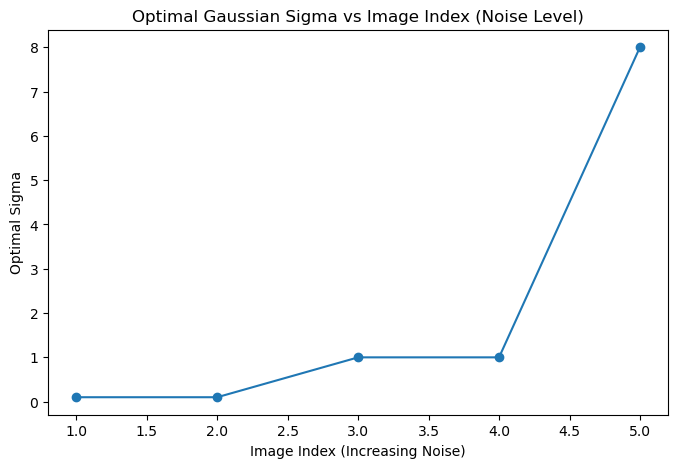

In [8]:
indices = np.arange(1, len(sorted_noisy_img_names) + 1, dtype = np.uint8)
best_sigmas = [s for _, s, _, _ in result.values()]

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(sorted_noisy_img_names) + 1), best_sigmas, marker='o', linestyle='-')
plt.title("Optimal Gaussian Sigma vs Image Index (Noise Level)")
plt.xlabel("Image Index (Increasing Noise)")
plt.ylabel("Optimal Sigma")
plt.show()

### Q2 Bilateral Filter

In [9]:
noisy_image = np.array(Image.open('data/noisybook.png').convert('L')).astype(np.float64)

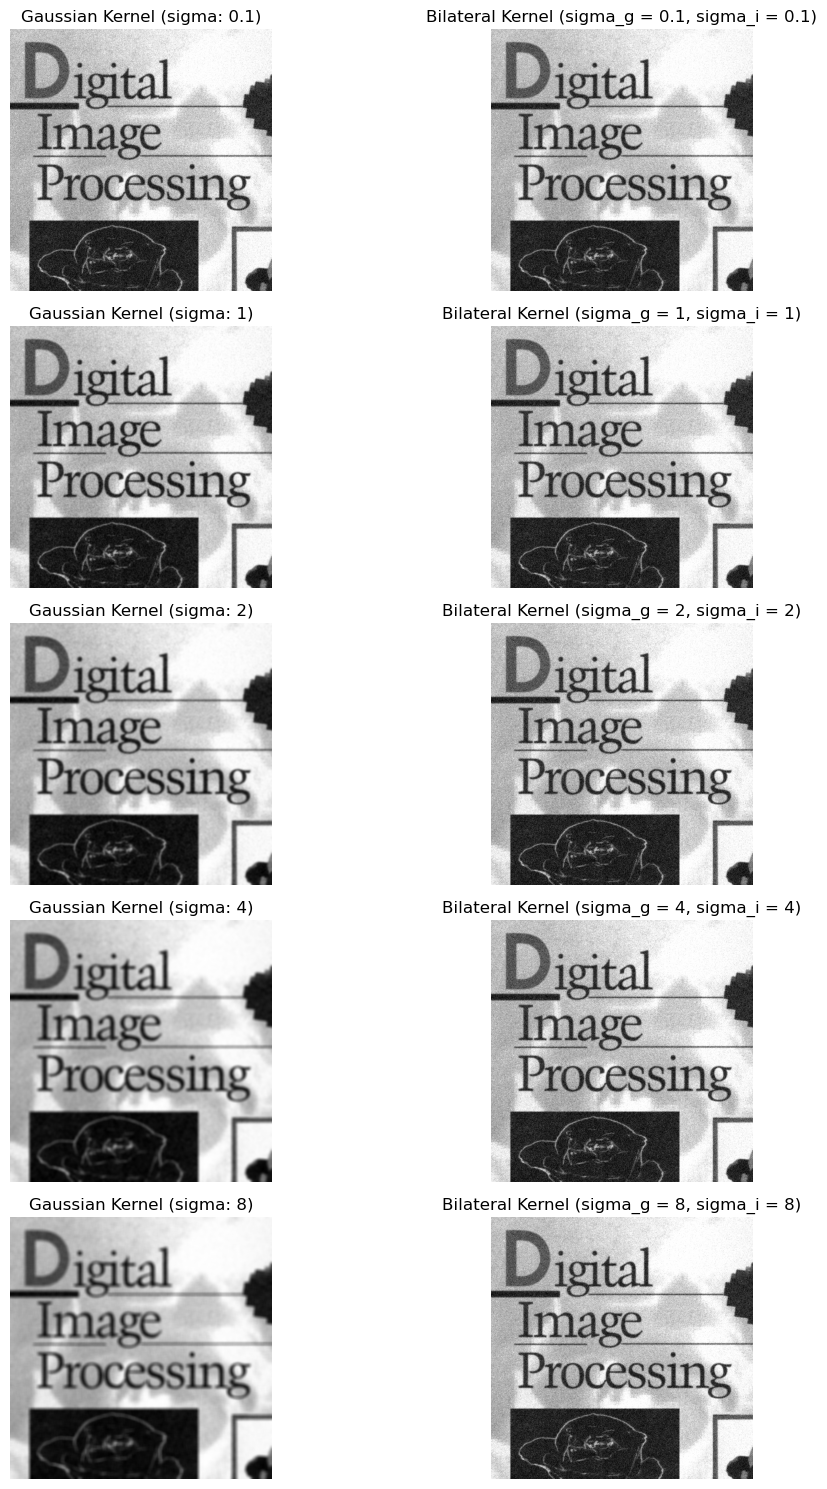

In [13]:
fig, axes = plt.subplots(nrows = 5, ncols = 2, figsize = (12, 15))

for i, sigma in enumerate(sigmas):
    gaussian_kernel = createGaussianKernel(P, sigma)
    gaussian_smooth_img = convolve2d(noisy_image, gaussian_kernel, mode='same', boundary='symm')
    bilateral_smooth_img = bilateralFilter(noisy_image, P, sigma, sigma)
    
    axes[i, 0].imshow(gaussian_smooth_img, cmap='gray')
    axes[i, 0].set_title(f'Gaussian Kernel (sigma: {sigma})')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(bilateral_smooth_img, cmap='gray')
    axes[i, 1].set_title(f'Bilateral Kernel (sigma_g = {sigma}, sigma_i = {sigma})')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

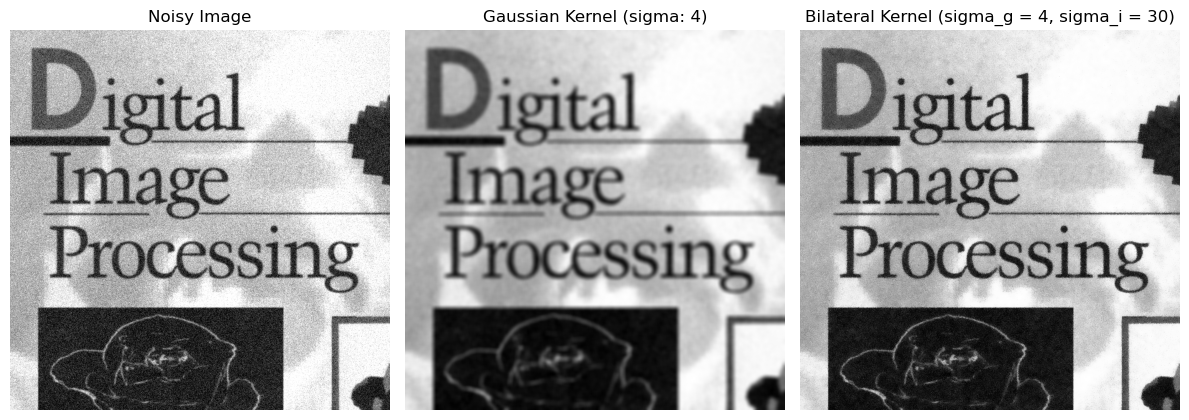

In [18]:
fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 15))

gaussian_kernel = createGaussianKernel(P, 4)
gaussian_smooth_img = convolve2d(noisy_image, gaussian_kernel, mode='same', boundary='symm')
bilateral_smooth_img = bilateralFilter(noisy_image, P, 4, 30)

axes[0].imshow(noisy_image, cmap='gray')
axes[0].set_title(f'Noisy Image')
axes[0].axis('off')

axes[1].imshow(gaussian_smooth_img, cmap='gray')
axes[1].set_title(f'Gaussian Kernel (sigma: {4})')
axes[1].axis('off')

axes[2].imshow(bilateral_smooth_img, cmap='gray')
axes[2].set_title(f'Bilateral Kernel (sigma_g = {4}, sigma_i = {30})')
axes[2].axis('off')

plt.tight_layout()
plt.show()